# Session 3 - Data Preprocessing
## From Raw Scraped Data to an Analytical Dataset

This notebook is part of the *Head of Data 101* end-to-end project.

Role of this notebook:
- Input: raw scraped data stored in `data/raw/`
- Output: cleaned and structured dataset stored in `data/processed/`
- Purpose: transform imperfect real-world data into a defensible analytical dataset

Design principles:
- Raw data is never modified
- Preprocessing decisions must be explicit and justifiable
- The notebook is intentionally simple and modular
- This is not modeling or optimization
- This notebook is a baseline example to be adapted by students

---


## 1. Loading the raw dataset

We start by loading the raw dataset exactly as it was collected during the scraping phase.

Important:
- Raw data must not be modified or overwritten
- All preprocessing outputs will be saved separately
- We assume the file is located in `data/raw/`

The raw file format is consistent across runs and should contain these columns:
- make, model, mileage, price, registration, fuel, country, brand, page

---


In [21]:
%pip install matplotlib


# Import the main libraries we will use in this notebook
import pandas as pd  # Work with tabular data (tables)
import numpy as np  # Work with numeric operations and arrays
from pathlib import Path  # Work with file paths in a clean way
from datetime import datetime  # Create timestamps for output files
import matplotlib.pyplot as plt  # Plot charts for data visualization
from IPython.display import display  # Show multiple tables in one cell


  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.0.0-cp313-cp313-win_amd64.whl (7.0 MB)
Using cached pyparsing-3.3.1-py3-none-any.whl (121 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -

In [22]:
# Find the repository root (the folder that contains the data/ directory)
# This makes the notebook work even if you run it from a subfolder
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'data').exists():
    # Move one folder up until we find data/
    repo_root = repo_root.parent

# Point to the raw data folder and list available files
raw_dir = repo_root / 'data' / 'raw'
raw_files = sorted(raw_dir.glob('*.csv'))
raw_files  # Display the available raw files


[WindowsPath('c:/Users/cfuen/OneDrive/Documentos/Clases/Ficheros para clase/Albert/Head of Data 101/Github repo/HeadOfData101/data/raw/autoscout24_listings_20251221_121306.csv'),
 WindowsPath('c:/Users/cfuen/OneDrive/Documentos/Clases/Ficheros para clase/Albert/Head of Data 101/Github repo/HeadOfData101/data/raw/autoscout24_listings_20251221_122247.csv'),
 WindowsPath('c:/Users/cfuen/OneDrive/Documentos/Clases/Ficheros para clase/Albert/Head of Data 101/Github repo/HeadOfData101/data/raw/autoscout24_listings_20251221_140155.csv'),
 WindowsPath('c:/Users/cfuen/OneDrive/Documentos/Clases/Ficheros para clase/Albert/Head of Data 101/Github repo/HeadOfData101/data/raw/autoscout24_listings_20251221_142336.csv')]

In [23]:
# IMPORTANT: edit this filename manually to match your scraping output
raw_filename = 'autoscout24_listings_20251221_142336.csv'

# Build the full path to the raw file
raw_path = raw_dir / raw_filename

# Stop early if the file does not exist (better than failing later)
if not raw_path.exists():
    raise FileNotFoundError(f'Raw file not found: {raw_path}')

# Load the raw data without changes
df_raw = pd.read_csv(raw_path)
df_raw.head()  # Show the first rows


,make,model,mileage,price,registration,fuel,country,brand,page
0,bmw,x1,293557,3400,02-2011,d,b,bmw,1
1,bmw,120,470000,2480,02-2011,d,d,bmw,1
2,bmw,114,197000,6950,01-2016,d,b,bmw,1
3,bmw,316,174771,799,12-2002,b,d,bmw,1
4,bmw,316,205000,3990,12-2010,d,i,bmw,1


In [25]:
# Check that the raw file has the expected format (fixed schema)
expected_columns = [
    'make', 'model', 'mileage', 'price', 'registration', 'fuel', 'country', 'brand', 'page'
]

# If the column list is different, stop and fix the input file first
if list(df_raw.columns) != expected_columns:
    raise ValueError(
        f'Unexpected columns. Expected: {expected_columns} | Found: {list(df_raw.columns)}'
    )
else:
    print('Column names are as expected.')


Column names are as expected.


## 2. Initial data inspection

Before cleaning anything, we must understand what kind of data we are working with.

At this stage we:
- Inspect column names
- Check data types
- Look at sample rows
- Quantify missing values

No cleaning decisions are taken yet.

---


In [26]:
# Check the size of the dataset (rows, columns)
df_raw.shape


(11977, 9)

In [27]:
# List the column names to confirm what we have
df_raw.columns


Index(['make', 'model', 'mileage', 'price', 'registration', 'fuel', 'country',
       'brand', 'page'],
      dtype='object')

In [28]:
# Show the data type of each column
# Notice that many columns may be objects (strings) even if they look numeric
df_raw.dtypes


make            object
model           object
mileage         object
price            int64
registration    object
fuel            object
country         object
brand           object
page             int64
dtype: object

In [29]:
# Show a sample of rows to get a feel for the data
df_raw.head(10)


,make,model,mileage,price,registration,fuel,country,brand,page
0,bmw,x1,293557,3400,02-2011,d,b,bmw,1
1,bmw,120,470000,2480,02-2011,d,d,bmw,1
2,bmw,114,197000,6950,01-2016,d,b,bmw,1
3,bmw,316,174771,799,12-2002,b,d,bmw,1
4,bmw,316,205000,3990,12-2010,d,i,bmw,1
5,bmw,220,185858,11990,02-2014,d,i,bmw,1
6,bmw,320,240000,6990,03-2012,d,i,bmw,1
7,bmw,318,190000,4500,05-2006,b,b,bmw,1
8,bmw,x1,216000,8799,06-2011,d,d,bmw,1
9,bmw,316,278826,6750,09-2015,d,nl,bmw,1


## 3. Understanding missing values

Missing values are common in scraped data and do not all mean the same thing.

In this section we:
- Identify which columns contain missing values
- Measure the proportion of missing values per column
- Discuss what missing values may represent in this dataset

At this stage, we only observe and document.

---


In [30]:
# Count missing values per column
missing_count = df_raw.isna().sum()

# Convert to percent to compare columns with different sizes
missing_percent = (missing_count / len(df_raw)) * 100

# Create a small summary table for easy reading
missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent.round(2),
}).sort_values('missing_percent', ascending=False)

missing_summary


,missing_count,missing_percent
make,0,0.0
model,0,0.0
mileage,0,0.0
price,0,0.0
registration,0,0.0
fuel,0,0.0
country,0,0.0
brand,0,0.0
page,0,0.0


**Optional decision: remove rows with missing values**

Run the next cell only if the class agrees to drop rows with missing data.
Otherwise, keep them and handle missing values in a different way (e.g., imputation).


In [ ]:
# OPTIONAL DECISION: drop rows with missing values
# Run this cell only if the class agrees that missing values should be removed
# You can also specify a subset of columns, for example: df = df.dropna(subset=['price', 'mileage'])
df = df.dropna()
df.shape


## 4. Data type correction and basic formatting

Many columns are not stored using the correct data types.

Typical issues include:
- Numeric values stored as strings
- Dates stored as text
- Mixed formats within the same column

In this section we:
- Convert columns to appropriate data types
- Standardize date formats
- Ensure numeric columns are truly numeric

These transformations are necessary for any downstream analysis.

---


In [31]:
# Work on a copy to keep raw data unchanged
df = df_raw.copy()

# Convert numeric columns (errors become NaN instead of crashing)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

# Keep the original registration text so we can inspect it later
df['registration_raw'] = df['registration']

# Convert registration to a real date (expected format: MM-YYYY)
df['registration_date'] = pd.to_datetime(df['registration'], format='%m-%Y', errors='coerce')

# Extract year and month for easier analysis
df['registration_year'] = df['registration_date'].dt.year
df['registration_month'] = df['registration_date'].dt.month

# Show a few converted rows as a quick check
df[['price', 'mileage', 'registration_date']].head()


,price,mileage,registration_date
0,3400,293557.0,2011-02-01
1,2480,470000.0,2011-02-01
2,6950,197000.0,2016-01-01
3,799,174771.0,2002-12-01
4,3990,205000.0,2010-12-01


## 5. Normalizing categorical variables

Some categorical variables appear as codes or inconsistent labels.

Examples:
- Country codes instead of country names
- Engine or fuel types encoded numerically
- Inconsistent capitalization or spelling

In this section we:
- Inspect categorical value distributions
- Map coded values to human-readable categories
- Standardize category labels

The goal is clarity and consistency, not perfect taxonomy.

---


In [32]:
# Standardize text columns to lowercase and remove extra spaces
df['make'] = df['make'].astype('string').str.strip().str.lower()
df['model'] = df['model'].astype('string').str.strip().str.lower()
df['brand'] = df['brand'].astype('string').str.strip().str.lower()
df['fuel'] = df['fuel'].astype('string').str.strip().str.lower()
df['country'] = df['country'].astype('string').str.strip().str.lower()

# Map fuel codes to readable labels (extend if new codes appear)
fuel_mapping = {
    'd': 'diesel',
    'b': 'petrol',
    'e': 'electric',
    'l': 'lpg',
    'h': 'hybrid',
}
df['fuel_clean'] = df['fuel'].map(fuel_mapping).fillna(df['fuel'])

# Map country codes to readable names (partial list for teaching)
country_mapping = {
    'd': 'germany',
    'b': 'belgium',
    'i': 'italy',
    'f': 'france',
    'nl': 'netherlands',
    'e': 'spain',
}
df['country_clean'] = df['country'].map(country_mapping).fillna(df['country'])

# Compare original vs cleaned values
df[['fuel', 'fuel_clean', 'country', 'country_clean']].head()


,fuel,fuel_clean,country,country_clean
0,d,diesel,b,belgium
1,d,diesel,d,germany
2,d,diesel,b,belgium
3,b,petrol,d,germany
4,d,diesel,i,italy


## 6. Detecting duplicated records

Scraped data often contains duplicated or near-duplicated records.

In this section we:
- Check for exact duplicate rows
- Explore which columns could define uniqueness
- Discuss whether rows represent unique cars or unique listings

A decision is made and clearly documented.

---


In [33]:
# Count exact duplicates across all columns
duplicate_count = df.duplicated().sum()
duplicate_count


np.int64(2)

**Optional decision: remove exact duplicate rows**

Run the next cell only if the class agrees duplicates should be removed.
If duplicates represent repeated listings, you may prefer to keep them.


In [34]:
# OPTIONAL DECISION: remove exact duplicate rows to keep one copy
# Run this cell only if the class agrees duplicates should be removed
df = df.drop_duplicates()
df.shape  # Check the new size


(11975, 15)

## 7. Outliers and extreme values

Extreme values may represent:
- Legitimate rare cases
- Data entry errors
- Scraping or parsing issues

In this section we:
- Identify outliers in key numerical variables
- Visualize distributions where helpful
- Decide how to handle extreme values (keep, cap, remove, or flag)

Outliers are not removed automatically.

---


In [42]:
# Function to flag outliers using the IQR (interquartile range) rule
def iqr_outlier_flags(series):
    # Compute the first and third quartiles
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    # The IQR is the spread between q3 and q1
    iqr = q3 - q1
    # Define lower and upper bounds for outliers
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    # Return True for values outside the bounds
    return (series < lower) | (series > upper)

# Create outlier flags for price and mileage
df['price_outlier_iqr'] = iqr_outlier_flags(df['price'])
df['mileage_outlier_iqr'] = iqr_outlier_flags(df['mileage'])

# Inspect a few rows to see the flags
df[['price', 'price_outlier_iqr', 'mileage', 'mileage_outlier_iqr']].head()


,price,price_outlier_iqr,mileage,mileage_outlier_iqr
2,6950,False,197000.0,False
3,799,False,174771.0,False
4,3990,False,205000.0,False
5,11990,False,185858.0,False
7,4500,False,190000.0,False


In [43]:
# Count how many price values are flagged as outliers
df['price_outlier_iqr'].value_counts(dropna=False)


price_outlier_iqr
False    10487
True       276
Name: count, dtype: int64

In [44]:
# Count how many mileage values are flagged as outliers
df['mileage_outlier_iqr'].value_counts(dropna=False)


mileage_outlier_iqr
False    10682
True        81
Name: count, dtype: int64

**Optional decision: remove outliers**

Run the next cell only if the class agrees to remove outliers.
Outliers can be valid rare cases, so deletion is not automatic.


In [41]:
# OPTIONAL DECISION: drop rows flagged as outliers
# Run this cell only if the class agrees to remove outliers
# This uses the IQR flags we created above
df = df[~(df['price_outlier_iqr'] | df['mileage_outlier_iqr'])]
df.shape


(10763, 17)

In [45]:
# Inspect the 10 most extreme price values (highest and lowest)
# This helps us see if extreme values look plausible or suspicious
price_cols = [
    'make', 'model', 'price', 'mileage', 'registration_date', 'fuel_clean', 'country_clean', 'page'
]
price_cols = [col for col in price_cols if col in df.columns]

price_top10 = df.dropna(subset=['price']).nlargest(10, 'price')[price_cols]
price_bottom10 = df.dropna(subset=['price']).nsmallest(10, 'price')[price_cols]

print('Top 10 prices')
display(price_top10)
print('Bottom 10 prices')
display(price_bottom10)


Top 10 prices


,make,model,price,mileage,registration_date,fuel_clean,country_clean,page
3847,bmw,m5,77500,106474.0,2007-07-01,petrol,netherlands,193
3920,bmw,m4,77499,23314.0,2022-09-01,petrol,germany,197
2461,bmw,m2,77490,16900.0,2023-11-01,petrol,italy,124
3305,bmw,i7,77490,11000.0,2024-06-01,electric,germany,166
11886,audi,rs3,77490,146.0,2023-06-01,petrol,italy,196
3786,bmw,m4,77450,15532.0,2024-02-01,petrol,germany,190
2823,bmw,340,77290,0.0,NaT,petrol,germany,142
2491,bmw,x7,77000,41229.0,2024-05-01,2,italy,125
2505,bmw,i8,77000,43986.0,2020-08-01,2,italy,126
3232,bmw,x7,76999,46141.0,2022-11-01,diesel,germany,162


Bottom 10 prices


,make,model,price,mileage,registration_date,fuel_clean,country_clean,page
4023,mercedes-benz,a 160,750,145000.0,1998-06-01,petrol,germany,2
4398,mercedes-benz,a 160,750,145000.0,1998-06-01,petrol,germany,21
3,bmw,316,799,174771.0,2002-12-01,petrol,germany,1
59,bmw,316,799,174771.0,2002-12-01,petrol,germany,4
4045,mercedes-benz,a 160,999,151000.0,2004-05-01,petrol,germany,3
4798,mercedes-benz,a 160,999,151000.0,2004-05-01,petrol,germany,41
4246,mercedes-benz,b 170,1650,213199.0,2006-11-01,petrol,netherlands,13
87,bmw,316,1790,170100.0,2002-09-01,petrol,germany,5
1399,bmw,316,1790,170100.0,2002-09-01,petrol,germany,71
4013,mercedes-benz,c 200,2400,214800.0,2004-10-01,petrol,germany,1


In [46]:
# Inspect the 10 most extreme mileage values (highest and lowest)
# This helps us detect very large or very small mileage values
mileage_cols = [
    'make', 'model', 'price', 'mileage', 'registration_date', 'fuel_clean', 'country_clean', 'page'
]
mileage_cols = [col for col in mileage_cols if col in df.columns]

mileage_top10 = df.dropna(subset=['mileage']).nlargest(10, 'mileage')[mileage_cols]
mileage_bottom10 = df.dropna(subset=['mileage']).nsmallest(10, 'mileage')[mileage_cols]

print('Top 10 mileage values')
display(mileage_top10)
print('Bottom 10 mileage values')
display(mileage_bottom10)


Top 10 mileage values


,make,model,price,mileage,registration_date,fuel_clean,country_clean,page
8030,audi,a7,14950,226463.0,2011-09-01,diesel,netherlands,3
8411,audi,a4,12999,226122.0,2016-06-01,petrol,netherlands,22
4598,mercedes-benz,b 180,6950,226000.0,2013-08-01,diesel,germany,31
13,bmw,318,7690,225900.0,2012-06-01,diesel,germany,1
239,bmw,318,7690,225900.0,2012-06-01,diesel,germany,13
11754,audi,a4,8860,225520.0,2010-01-01,diesel,a,189
2111,bmw,320,19900,225000.0,1995-07-01,petrol,belgium,106
4251,mercedes-benz,cla 220,12950,225000.0,2016-06-01,diesel,germany,13
11633,audi,a4,13700,225000.0,2016-10-01,diesel,italy,183
1949,bmw,850,69890,224845.0,1994-10-01,petrol,germany,98


Bottom 10 mileage values


,make,model,price,mileage,registration_date,fuel_clean,country_clean,page
633,bmw,230,49490,0.0,NaT,petrol,germany,32
775,bmw,i4,43552,0.0,NaT,electric,germany,39
780,bmw,ix1,49690,0.0,NaT,electric,germany,40
808,bmw,220,49890,0.0,NaT,diesel,germany,41
1791,bmw,i4,53990,0.0,NaT,electric,germany,90
2044,bmw,320,49900,0.0,NaT,diesel,germany,103
2066,bmw,540,76390,0.0,NaT,diesel,germany,104
2313,bmw,120,29799,0.0,NaT,petrol,germany,116
2457,bmw,ix1,53450,0.0,NaT,electric,germany,123
2631,bmw,i4,43553,0.0,NaT,electric,germany,132


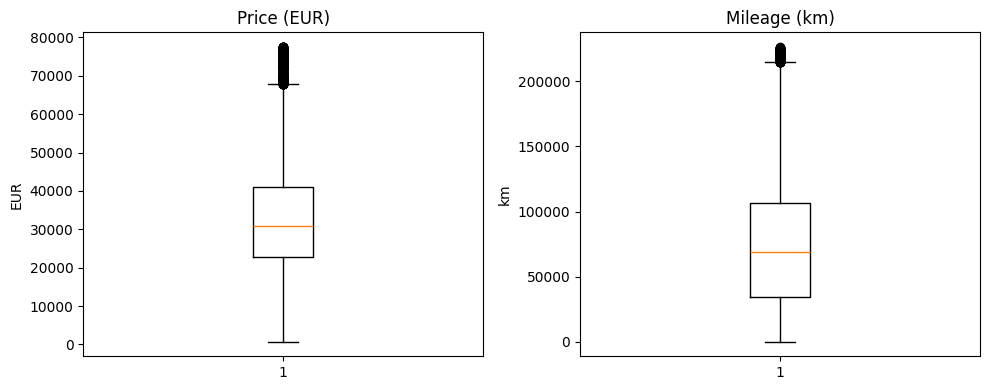

In [47]:
# Box-and-whisker plots (boxplots) to visualize outliers
# The box shows the middle 50% of the data, and dots beyond the whiskers are outliers
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].boxplot(df['price'].dropna(), vert=True)
ax[0].set_title('Price (EUR)')
ax[0].set_ylabel('EUR')

ax[1].boxplot(df['mileage'].dropna(), vert=True)
ax[1].set_title('Mileage (km)')
ax[1].set_ylabel('km')

plt.tight_layout()


## 8. Detecting logically inconsistent values

Some errors are not statistical outliers but logical inconsistencies.

Examples:
- Very high mileage for very recent registration dates
- Negative or zero values where not meaningful
- Incompatible combinations of variables

In this section we:
- Define simple logical sanity checks
- Identify suspicious records
- Decide how to handle them

This step increases trust in the dataset.

---


In [48]:
# Use today's date to check for impossible future dates
today = pd.Timestamp.today()

# Basic sanity checks for numeric values
df['invalid_price'] = df['price'] <= 0
df['invalid_mileage'] = df['mileage'] <= 0

# Registration dates should not be in the future
df['future_registration'] = df['registration_date'] > today

# Example of a suspicious combination: very new car with huge mileage
recent_year = today.year - 1
df['recent_with_high_mileage'] = (df['registration_year'] >= recent_year) & (df['mileage'] > 300000)

# Combine any logical issues into a single flag
logical_issue_cols = [
    'invalid_price',
    'invalid_mileage',
    'future_registration',
    'recent_with_high_mileage',
]
df['logical_issue'] = df[logical_issue_cols].any(axis=1)

# Count how many rows fail each rule
df[logical_issue_cols + ['logical_issue']].sum()


invalid_price                0
invalid_mileage             31
future_registration          0
recent_with_high_mileage     0
logical_issue               31
dtype: int64

**Optional decision: remove logically inconsistent rows**

Run the next cell only if the class agrees these rows are errors.
If you keep them, document the potential risk for later analysis.


In [49]:
# OPTIONAL DECISION: drop rows with logical inconsistencies
# Run this cell only if the class agrees to remove these rows
df = df[~df['logical_issue']]
df.shape


(10732, 22)

## 9. Feature selection and basic feature engineering

Not all collected variables are equally useful.

In this section we:
- Remove columns that are irrelevant or redundant
- Rename columns to clear, consistent names
- Create simple derived features if appropriate

Complex transformations are intentionally avoided at this stage.

---


In [50]:
# Decide which columns to keep for the analytical dataset
columns_to_keep = [
    'make',
    'model',
    'brand',
    'price',
    'mileage',
    'registration_date',
    'registration_year',
    'registration_month',
    'fuel_clean',
    'country_clean',
    'page',
    'price_outlier_iqr',
    'mileage_outlier_iqr',
    'logical_issue',
]

# Keep only those columns (fixed schema, so all should exist)
df_final = df[columns_to_keep].copy()

# Rename columns for clarity and consistency
df_final = df_final.rename(columns={
    'price': 'price_eur',
    'mileage': 'mileage_km',
    'fuel_clean': 'fuel_type',
    'country_clean': 'listing_country',
})

# Simple feature: car age in years
df_final['age_years'] = today.year - df_final['registration_year']

df_final.head()


,make,model,brand,price_eur,mileage_km,registration_date,registration_year,registration_month,fuel_type,listing_country,page,price_outlier_iqr,mileage_outlier_iqr,logical_issue,age_years
2,bmw,114,bmw,6950,197000.0,2016-01-01,2016.0,1.0,diesel,belgium,1,False,False,False,9.0
3,bmw,316,bmw,799,174771.0,2002-12-01,2002.0,12.0,petrol,germany,1,False,False,False,23.0
4,bmw,316,bmw,3990,205000.0,2010-12-01,2010.0,12.0,diesel,italy,1,False,False,False,15.0
5,bmw,220,bmw,11990,185858.0,2014-02-01,2014.0,2.0,diesel,italy,1,False,False,False,11.0
7,bmw,318,bmw,4500,190000.0,2006-05-01,2006.0,5.0,petrol,belgium,1,False,False,False,19.0


## 10. Final validation checks

Before saving the processed dataset, we perform final checks.

These include:
- Verifying expected columns are present
- Checking value ranges
- Confirming no unintended data loss occurred

If something looks suspicious, it should be addressed now.

---


In [51]:
# Final dataset size
df_final.shape


(10732, 15)

In [52]:
# Quick overview of distributions and missing values
df_final.describe(include='all').transpose()


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
make,10732,3,audi,3657,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,10732,336,a3,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,10732,3,audi,3657,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_eur,10732.0,NaN,NaN,NaN,33020.587123,750.0,22900.0,30749.0,40841.75,77500.0,14808.932656
mileage_km,10721.0,NaN,NaN,NaN,76173.245499,1.0,34845.0,69139.0,106774.0,226463.0,51365.539015
registration_date,10696,NaN,NaN,NaN,2020-05-13 12:35:32.535527424,1970-11-01 00:00:00,2018-09-01 00:00:00,2021-07-01 00:00:00,2023-02-01 00:00:00,2025-12-01 00:00:00,NaN
registration_year,10696.0,NaN,NaN,NaN,2019.91221,1970.0,2018.0,2021.0,2023.0,2025.0,4.563392
registration_month,10696.0,NaN,NaN,NaN,6.45101,1.0,4.0,6.0,9.0,12.0,3.390115
fuel_type,10732,8,petrol,4325,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listing_country,10732,8,germany,5373,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 11. Saving the processed dataset

The cleaned dataset is saved separately from the raw data.

Best practices applied:
- Save to `data/processed/`
- Use a clear and descriptive filename
- Do not manually edit the output file

This dataset will be used in the next session for cloud storage.

---


In [53]:
# Create the processed folder if it does not exist
processed_dir = repo_root / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

# Add a timestamp so each run creates a new file
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_path = processed_dir / f'autoscout24_listings_processed_{timestamp}.csv'

# Save without the index column
df_final.to_csv(output_path, index=False)
print('Saved to', output_path)


Saved to c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\data\processed\autoscout24_listings_processed_20251225_193423.csv


## 12. Summary of preprocessing decisions

This final section summarizes the main decisions taken during preprocessing:
- Missing values were inspected and documented before any action
- `price` and `mileage` were converted to numeric values
- `registration` was parsed to a real date and split into year and month
- Fuel and country codes were mapped to readable labels (with room to extend)
- Exact duplicate rows were removed
- Outliers were flagged (not removed) using the IQR rule
- Logical inconsistencies were flagged for review
- A smaller set of clear, consistent columns was selected

Documenting decisions is part of professional data work.
